# Valio Aimo Sales & Deliveries Analysis

## Challenge Overview
This notebook analyzes sales order and delivery data to identify patterns that can help predict missing items and proactively contact customers.

**Key Objectives:**
1. Identify products with high shortage/delivery failure risk
2. Identify customers most affected by delivery discrepancies
3. Discover temporal patterns (seasonality, day of week, picking time windows)
4. Analyze picking patterns and delivery reliability
5. Create risk scoring metrics for AI agent prioritization
6. Identify when shortages are discovered (at picking vs delivery)


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


## 1. Data Loading and Initial Exploration


In [2]:
# Load the sales and deliveries data
file_path = 'valio_aimo_sales_and_deliveries_junction_2025.csv'
df = pd.read_csv(file_path)

print(f"Sales & Deliveries data shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head(10)


Sales & Deliveries data shape: (7357509, 18)

Column names: ['order_number', 'order_created_date', 'order_created_time', 'requested_delivery_date', 'customer_number', 'order_row_number', 'product_code', 'order_qty', 'sales_unit', 'delivery_number', 'plant', 'storage_location', 'delivered_qty', 'transfer_number', 'warehouse_number', 'picking_confirmed_date', 'picking_confirmed_time', 'picking_picked_qty']

First few rows:


,order_number,order_created_date,order_created_time,requested_delivery_date,customer_number,order_row_number,product_code,order_qty,sales_unit,delivery_number,plant,storage_location,delivered_qty,transfer_number,warehouse_number,picking_confirmed_date,picking_confirmed_time,picking_picked_qty
0,10000000,2024-09-01,336,2024-09-02,33258,10,409510,5.00,ST,20000000.00,30588.00,2012.00,5.00,30000212.00,3001.00,2024-09-01,203837.00,5.00
1,10000000,2024-09-01,336,2024-09-02,33258,40,410914,12.00,ST,20000000.00,30588.00,2012.00,12.00,30000212.00,3001.00,2024-09-01,203734.00,12.00
2,10000000,2024-09-01,336,2024-09-02,33258,50,406587,4.00,ST,20000000.00,30588.00,2012.00,4.00,30000211.00,3001.00,2024-09-01,204149.00,4.00
3,10000000,2024-09-01,336,2024-09-02,33258,60,406588,4.00,ST,20000000.00,30588.00,2012.00,4.00,30000211.00,3001.00,2024-09-01,204124.00,4.00
4,10000000,2024-09-01,336,2024-09-02,33258,70,401369,8.00,BOT,20000000.00,30588.00,2012.00,8.00,30000211.00,3001.00,2024-09-01,205255.00,8.00
5,10000000,2024-09-01,336,2024-09-02,33258,80,410457,3.00,ST,20000000.00,30588.00,2012.00,3.00,30000211.00,3001.00,2024-09-01,204713.00,3.00
6,10000000,2024-09-01,336,2024-09-02,33258,90,416116,4.00,ST,20000000.00,30588.00,2012.00,4.00,30000211.00,3001.00,2024-09-01,204439.00,4.00
7,10000000,2024-09-01,336,2024-09-02,33258,100,402358,8.00,BOT,20000000.00,30588.00,2012.00,8.00,30000211.00,3001.00,2024-09-01,205112.00,8.00
8,10000000,2024-09-01,336,2024-09-02,33258,110,415997,12.00,ST,20000000.00,30588.00,2012.00,12.00,30000211.00,3001.00,2024-09-01,204950.00,12.00
9,10000000,2024-09-01,336,2024-09-02,33258,120,401042,10.00,BAG,20000001.00,30588.00,2012.00,10.00,30000016.00,3001.00,2024-09-01,204917.00,10.00


In [3]:
# Basic data info
print("=== SALES & DELIVERIES DATA INFO ===")
df.info()
print("\n\n=== DATA DESCRIPTION ===")
df.describe()


=== SALES & DELIVERIES DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7357509 entries, 0 to 7357508
Data columns (total 18 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   order_number             int64  
 1   order_created_date       object 
 2   order_created_time       int64  
 3   requested_delivery_date  object 
 4   customer_number          int64  
 5   order_row_number         int64  
 6   product_code             int64  
 7   order_qty                float64
 8   sales_unit               object 
 9   delivery_number          float64
 10  plant                    float64
 11  storage_location         float64
 12  delivered_qty            float64
 13  transfer_number          float64
 14  warehouse_number         float64
 15  picking_confirmed_date   object 
 16  picking_confirmed_time   float64
 17  picking_picked_qty       float64
dtypes: float64(9), int64(5), object(4)
memory usage: 1010.4+ MB


=== DATA DESCRIPTION ==

,order_number,order_created_time,customer_number,order_row_number,product_code,order_qty,delivery_number,plant,storage_location,delivered_qty,transfer_number,warehouse_number,picking_confirmed_time,picking_picked_qty
count,7357509.00,7357509.00,7357509.00,7357509.00,7357509.00,7357509.00,7210139.00,7210139.00,7210125.00,7210139.00,7184117.00,7184117.00,7184117.00,7184117.00
mean,10346696.65,124795.91,34719.67,155.24,406634.26,4.58,20525502.39,23754.58,2010.41,4.60,30626358.45,3001.18,120984.34,4.15
std,200790.98,31638.94,24253.53,149.37,5389.00,12.55,299198.13,12469.35,18.70,12.69,1782832.18,0.68,65115.70,11.34
min,10000000.00,0.00,30006.00,10.00,400001.00,0.00,20000000.00,1000.00,1001.00,0.00,10000005.00,3000.00,0.00,0.00
25%,10174485.00,102820.00,31897.00,40.00,401411.00,1.00,20268646.00,30588.00,2010.00,1.00,30337569.00,3001.00,74845.00,1.00
50%,10343766.00,123630.00,33284.00,110.00,405270.00,2.00,20527019.00,30588.00,2012.00,2.00,30671086.00,3001.00,130350.00,2.00
75%,10520688.00,143716.00,34351.00,220.00,410974.00,5.00,20785330.00,30588.00,2012.00,5.00,31242102.00,3001.00,171102.00,4.00
max,10696990.00,235957.00,402665.00,2680.00,417545.00,5760.00,21042241.00,30588.00,30588.00,5760.00,32017369.00,3003.00,235959.00,5760.00


In [4]:
# Convert date columns to datetime
df['order_created_date'] = pd.to_datetime(df['order_created_date'])
df['requested_delivery_date'] = pd.to_datetime(df['requested_delivery_date'])
df['picking_confirmed_date'] = pd.to_datetime(df['picking_confirmed_date'])

# Create additional derived columns
df['days_to_delivery'] = (df['requested_delivery_date'] - df['order_created_date']).dt.days
df['shortage_qty'] = df['order_qty'] - df['delivered_qty']
df['shortage_pct'] = (df['shortage_qty'] / df['order_qty'] * 100).replace([np.inf, -np.inf], 0)
df['has_shortage'] = df['shortage_qty'] > 0
df['over_delivery'] = df['delivered_qty'] > df['order_qty']
df['exact_match'] = df['delivered_qty'] == df['order_qty']

# Picking discrepancies
df['picking_shortage_qty'] = df['order_qty'] - df['picking_picked_qty']
df['picking_shortage_pct'] = (df['picking_shortage_qty'] / df['order_qty'] * 100).replace([np.inf, -np.inf], 0)
df['has_picking_shortage'] = df['picking_shortage_qty'] > 0
df['picked_vs_delivered_diff'] = df['picking_picked_qty'] - df['delivered_qty']

# Extract temporal features
df['order_created_year'] = df['order_created_date'].dt.year
df['order_created_month'] = df['order_created_date'].dt.month
df['order_created_week'] = df['order_created_date'].dt.isocalendar().week
df['order_created_dayofweek'] = df['order_created_date'].dt.dayofweek
df['order_created_dayname'] = df['order_created_date'].dt.day_name()

# Extract picking time (convert time string to minutes from midnight for analysis)
def time_to_minutes(time_str):
    if pd.isna(time_str) or time_str == '':
        return np.nan
    try:
        # Format: HHMMSS or HHMM
        time_str = str(int(float(time_str))).zfill(6)[:6]
        hours = int(time_str[:2])
        minutes = int(time_str[2:4])
        return hours * 60 + minutes
    except:
        return np.nan

df['picking_confirmed_time_minutes'] = df['picking_confirmed_time'].apply(time_to_minutes)
df['picking_hour'] = df['picking_confirmed_time_minutes'] // 60
df['picking_time_window'] = pd.cut(df['picking_confirmed_time_minutes'], 
                                    bins=[0, 360, 720, 1080, 1440], 
                                    labels=['Early (0-6h)', 'Morning (6-12h)', 'Afternoon (12-18h)', 'Evening (18-24h)'])

print(f"Date range: {df['order_created_date'].min()} to {df['order_created_date'].max()}")
print(f"Total unique orders: {df['order_number'].nunique()}")
print(f"Total unique products: {df['product_code'].nunique()}")
print(f"Total unique customers: {df['customer_number'].nunique()}")
print(f"Total unique deliveries: {df['delivery_number'].nunique()}")
print(f"Total unique transfer orders: {df['transfer_number'].nunique()}")
print(f"\nRows with shortages (delivered < ordered): {df['has_shortage'].sum()} ({df['has_shortage'].sum()/len(df)*100:.2f}%)")
print(f"Rows with picking shortages: {df['has_picking_shortage'].sum()} ({df['has_picking_shortage'].sum()/len(df)*100:.2f}%)")
print(f"Rows with over-delivery: {df['over_delivery'].sum()} ({df['over_delivery'].sum()/len(df)*100:.2f}%)")


Date range: 2024-09-01 00:00:00 to 2025-09-30 00:00:00
Total unique orders: 696991
Total unique products: 15236
Total unique customers: 5282
Total unique deliveries: 1042242
Total unique transfer orders: 2057562

Rows with shortages (delivered < ordered): 164790 (2.24%)
Rows with picking shortages: 776447 (10.55%)
Rows with over-delivery: 710454 (9.66%)


## Understanding Orders, Deliveries, and Transfer Orders

**Why are there more deliveries than orders?**  
**Why are there more transfer orders than deliveries?**

According to the README:
- **A sales order row might have several deliveries** - A delivery groups all qualifying orders together for logistics purposes (picking, shipment)
- **A delivery might have several transfer orders** - A transfer order represents a picking list

**What this means in practice:**

1. **One Order → Multiple Deliveries** can happen when:
   - An order is split across multiple delivery dates
   - An order is split across multiple warehouses/plants
   - Partial shipments due to stock availability
   - Different products from the same order go to different locations

2. **One Delivery → Multiple Transfer Orders** can happen when:
   - A delivery is split into multiple picking lists (transfer orders)
   - Different products are picked from different warehouse locations
   - Picking is done in batches at different times
   - Different storage locations require separate picking lists

**Example scenario:**
- Customer orders 10 products (1 order, 1 order_row_number)
- 3 products are available at Plant A, 7 at Plant B → **2 deliveries**
- Plant A's delivery needs picking from 2 different storage locations → **2 transfer orders**
- Plant B's delivery needs picking from 3 different storage locations → **3 transfer orders**
- **Total: 1 order → 2 deliveries → 5 transfer orders**

This is why we see:
- **696,991 unique orders** 
- **1,042,242 unique deliveries** (~1.5x more - orders split into deliveries)
- **2,057,562 unique transfer orders** (~2x more than deliveries - deliveries split into picking lists)


In [ ]:
# Analyze the relationship between orders, deliveries, and transfer orders
print("=" * 80)
print("ORDERS → DELIVERIES → TRANSFER ORDERS RELATIONSHIP ANALYSIS")
print("=" * 80)

# Calculate ratios
orders_count = df['order_number'].nunique()
deliveries_count = df['delivery_number'].nunique()
transfer_orders_count = df['transfer_number'].nunique()

print(f"\n1. BASIC COUNTS:")
print(f"   Unique Orders: {orders_count:,}")
print(f"   Unique Deliveries: {deliveries_count:,}")
print(f"   Unique Transfer Orders: {transfer_orders_count:,}")

print(f"\n2. RATIOS:")
print(f"   Deliveries per Order: {deliveries_count/orders_count:.2f}x")
print(f"   Transfer Orders per Delivery: {transfer_orders_count/deliveries_count:.2f}x")
print(f"   Transfer Orders per Order: {transfer_orders_count/orders_count:.2f}x")

# Analyze how many deliveries per order
deliveries_per_order = df.groupby('order_number')['delivery_number'].nunique()
print(f"\n3. DELIVERIES PER ORDER DISTRIBUTION:")
print(f"   Orders with 1 delivery: {(deliveries_per_order == 1).sum():,} ({(deliveries_per_order == 1).sum()/len(deliveries_per_order)*100:.1f}%)")
print(f"   Orders with 2+ deliveries: {(deliveries_per_order > 1).sum():,} ({(deliveries_per_order > 1).sum()/len(deliveries_per_order)*100:.1f}%)")
print(f"   Orders with 3+ deliveries: {(deliveries_per_order >= 3).sum():,} ({(deliveries_per_order >= 3).sum()/len(deliveries_per_order)*100:.1f}%)")
print(f"   Orders with 5+ deliveries: {(deliveries_per_order >= 5).sum():,} ({(deliveries_per_order >= 5).sum()/len(deliveries_per_order)*100:.1f}%)")
print(f"   Max deliveries for a single order: {deliveries_per_order.max()}")

# Analyze how many transfer orders per delivery
transfer_per_delivery = df.groupby('delivery_number')['transfer_number'].nunique()
print(f"\n4. TRANSFER ORDERS PER DELIVERY DISTRIBUTION:")
print(f"   Deliveries with 1 transfer order: {(transfer_per_delivery == 1).sum():,} ({(transfer_per_delivery == 1).sum()/len(transfer_per_delivery)*100:.1f}%)")
print(f"   Deliveries with 2+ transfer orders: {(transfer_per_delivery > 1).sum():,} ({(transfer_per_delivery > 1).sum()/len(transfer_per_delivery)*100:.1f}%)")
print(f"   Deliveries with 3+ transfer orders: {(transfer_per_delivery >= 3).sum():,} ({(transfer_per_delivery >= 3).sum()/len(transfer_per_delivery)*100:.1f}%)")
print(f"   Deliveries with 5+ transfer orders: {(transfer_per_delivery >= 5).sum():,} ({(transfer_per_delivery >= 5).sum()/len(transfer_per_delivery)*100:.1f}%)")
print(f"   Max transfer orders for a single delivery: {transfer_per_delivery.max()}")

# Show examples of orders with multiple deliveries
print(f"\n5. EXAMPLE: Orders with Multiple Deliveries (Top 10):")
multi_delivery_orders = deliveries_per_order[deliveries_per_order > 1].sort_values(ascending=False).head(10)
for order_num, delivery_count in multi_delivery_orders.items():
    order_deliveries = df[df['order_number'] == order_num]['delivery_number'].unique()
    print(f"   Order {order_num}: {delivery_count} deliveries {order_deliveries[:5]}...")

# Show examples of deliveries with multiple transfer orders
print(f"\n6. EXAMPLE: Deliveries with Multiple Transfer Orders (Top 10):")
multi_transfer_deliveries = transfer_per_delivery[transfer_per_delivery > 1].sort_values(ascending=False).head(10)
for delivery_num, transfer_count in multi_transfer_deliveries.items():
    delivery_transfers = df[df['delivery_number'] == delivery_num]['transfer_number'].unique()
    print(f"   Delivery {delivery_num}: {transfer_count} transfer orders {delivery_transfers[:5]}...")

print("\n" + "=" * 80)
print("KEY INSIGHT: When analyzing shortages, we need to aggregate by (order_number, order_row_number)")
print("because the same order row can appear in multiple deliveries/transfer orders.")
print("The 'delivered_qty' field already contains the total delivered quantity per order row.")
print("=" * 80)


## 2. Handling Multiple Deliveries and Transfer Orders

According to the README, a sales order row might have several deliveries and a delivery might have several transfer orders. We need to aggregate by `order_number` + `order_row_number` to get the true delivered quantity.


In [5]:
# Group by order_number and order_row_number to handle multiple deliveries and transfer orders
# According to README: delivered_qty has the total delivered quantity of a sales order row
aggregated = df.groupby(['order_number', 'order_row_number']).agg({
    'customer_number': 'first',
    'order_created_date': 'first',
    'requested_delivery_date': 'first',
    'product_code': 'first',
    'order_qty': 'first',  # Should be the same for all deliveries/transfers
    'sales_unit': 'first',
    'delivered_qty': 'first',  # README says this is already the total delivered quantity
    'plant': 'first',
    'storage_location': 'first',
    'delivery_number': 'nunique',  # Count unique deliveries
    'transfer_number': 'nunique',  # Count unique transfer orders
    'picking_picked_qty': 'max',  # Maximum picked quantity (or sum if multiple picks)
    'picking_confirmed_date': 'first',
    'picking_hour': 'first',
    'picking_time_window': 'first',
    'order_created_month': 'first',
    'order_created_week': 'first',
    'order_created_dayofweek': 'first',
    'order_created_dayname': 'first',
    'days_to_delivery': 'first'
}).reset_index()

# Recalculate shortage metrics after aggregation
aggregated['shortage_qty'] = aggregated['order_qty'] - aggregated['delivered_qty']
aggregated['shortage_pct'] = (aggregated['shortage_qty'] / aggregated['order_qty'] * 100).replace([np.inf, -np.inf], 0)
aggregated['has_shortage'] = aggregated['shortage_qty'] > 0
aggregated['over_delivery'] = aggregated['delivered_qty'] > aggregated['order_qty']
aggregated['exact_match'] = aggregated['delivered_qty'] == aggregated['order_qty']

# Picking discrepancies
aggregated['picking_shortage_qty'] = aggregated['order_qty'] - aggregated['picking_picked_qty']
aggregated['picking_shortage_pct'] = (aggregated['picking_shortage_qty'] / aggregated['order_qty'] * 100).replace([np.inf, -np.inf], 0)
aggregated['has_picking_shortage'] = aggregated['picking_shortage_qty'] > 0
aggregated['picked_vs_delivered_diff'] = aggregated['picking_picked_qty'] - aggregated['delivered_qty']

# Shortage discovered at picking vs discovered later
aggregated['shortage_discovered_at_picking'] = (aggregated['has_picking_shortage'] & aggregated['has_shortage'])
aggregated['shortage_discovered_after_picking'] = (~aggregated['has_picking_shortage'] & aggregated['has_shortage'])

print(f"Original rows: {len(df)}")
print(f"Aggregated rows: {len(aggregated)}")
print(f"Rows with multiple deliveries/transfers: {len(df) - len(aggregated)}")
print(f"\nAfter aggregation:")
print(f"Orders with shortages: {aggregated['has_shortage'].sum()} ({aggregated['has_shortage'].sum()/len(aggregated)*100:.2f}%)")
print(f"Orders with picking shortages: {aggregated['has_picking_shortage'].sum()} ({aggregated['has_picking_shortage'].sum()/len(aggregated)*100:.2f}%)")
print(f"Orders with shortages discovered at picking: {aggregated['shortage_discovered_at_picking'].sum()}")
print(f"Orders with shortages discovered after picking: {aggregated['shortage_discovered_after_picking'].sum()}")

# Count deliveries per order
delivery_counts = df.groupby(['order_number', 'order_row_number']).size()
print(f"\nMultiple delivery/transfer statistics:")
print(delivery_counts.describe())


Original rows: 7357509
Aggregated rows: 7135108
Rows with multiple deliveries/transfers: 222401

After aggregation:
Orders with shortages: 148489 (2.08%)
Orders with picking shortages: 560936 (7.86%)
Orders with shortages discovered at picking: 126762
Orders with shortages discovered after picking: 21727

Multiple delivery/transfer statistics:
count   7135108.00
mean          1.03
std           0.28
min           1.00
25%           1.00
50%           1.00
75%           1.00
max          70.00
dtype: float64


## 3. Product Shortage Analysis


In [6]:
# Product-level shortage analysis
product_stats = aggregated.groupby('product_code').agg({
    'order_number': 'count',  # Total orders
    'has_shortage': 'sum',  # Count of shortages
    'shortage_qty': 'sum',  # Total shortage quantity
    'order_qty': 'sum',  # Total ordered
    'delivered_qty': 'sum',  # Total delivered
    'has_picking_shortage': 'sum',  # Shortages discovered at picking
    'shortage_pct': 'mean',  # Average shortage percentage
    'plant': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0],
    'storage_location': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()

product_stats.columns = ['product_code', 'total_orders', 'shortage_count', 'total_shortage_qty', 
                        'total_ordered_qty', 'total_delivered_qty', 'picking_shortage_count',
                        'avg_shortage_pct', 'primary_plant', 'primary_storage']

# Calculate shortage rate
product_stats['shortage_rate'] = (product_stats['shortage_count'] / product_stats['total_orders'] * 100)
product_stats['fulfillment_rate'] = (product_stats['total_delivered_qty'] / product_stats['total_ordered_qty'] * 100)
product_stats['picking_shortage_rate'] = (product_stats['picking_shortage_count'] / product_stats['total_orders'] * 100)

# Risk score: combination of shortage rate and total shortage quantity
product_stats['risk_score'] = (
    (product_stats['shortage_rate'] / 100) * 0.6 +  # 60% weight on frequency
    (1 - product_stats['fulfillment_rate'] / 100) * 0.4  # 40% weight on severity
) * 100

print("Top 20 Products by Risk Score:")
print(product_stats.nlargest(20, 'risk_score')[['product_code', 'total_orders', 'shortage_count', 
                                                  'shortage_rate', 'picking_shortage_rate', 
                                                  'fulfillment_rate', 'risk_score']])


Top 20 Products by Risk Score:
      product_code  total_orders  shortage_count  shortage_rate  \
271         400292            11              11         100.00   
459         400493             1               1         100.00   
1829        402026             2               2         100.00   
2241        402471             1               1         100.00   
2295        402534             1               1         100.00   
3156        403520             1               1         100.00   
3686        404135             1               1         100.00   
3687        404136             1               1         100.00   
3821        404281             1               1         100.00   
3907        404378             3               3         100.00   
3964        404438             3               3         100.00   
4142        404639             1               1         100.00   
4147        404645             1               1         100.00   
4389        404921             

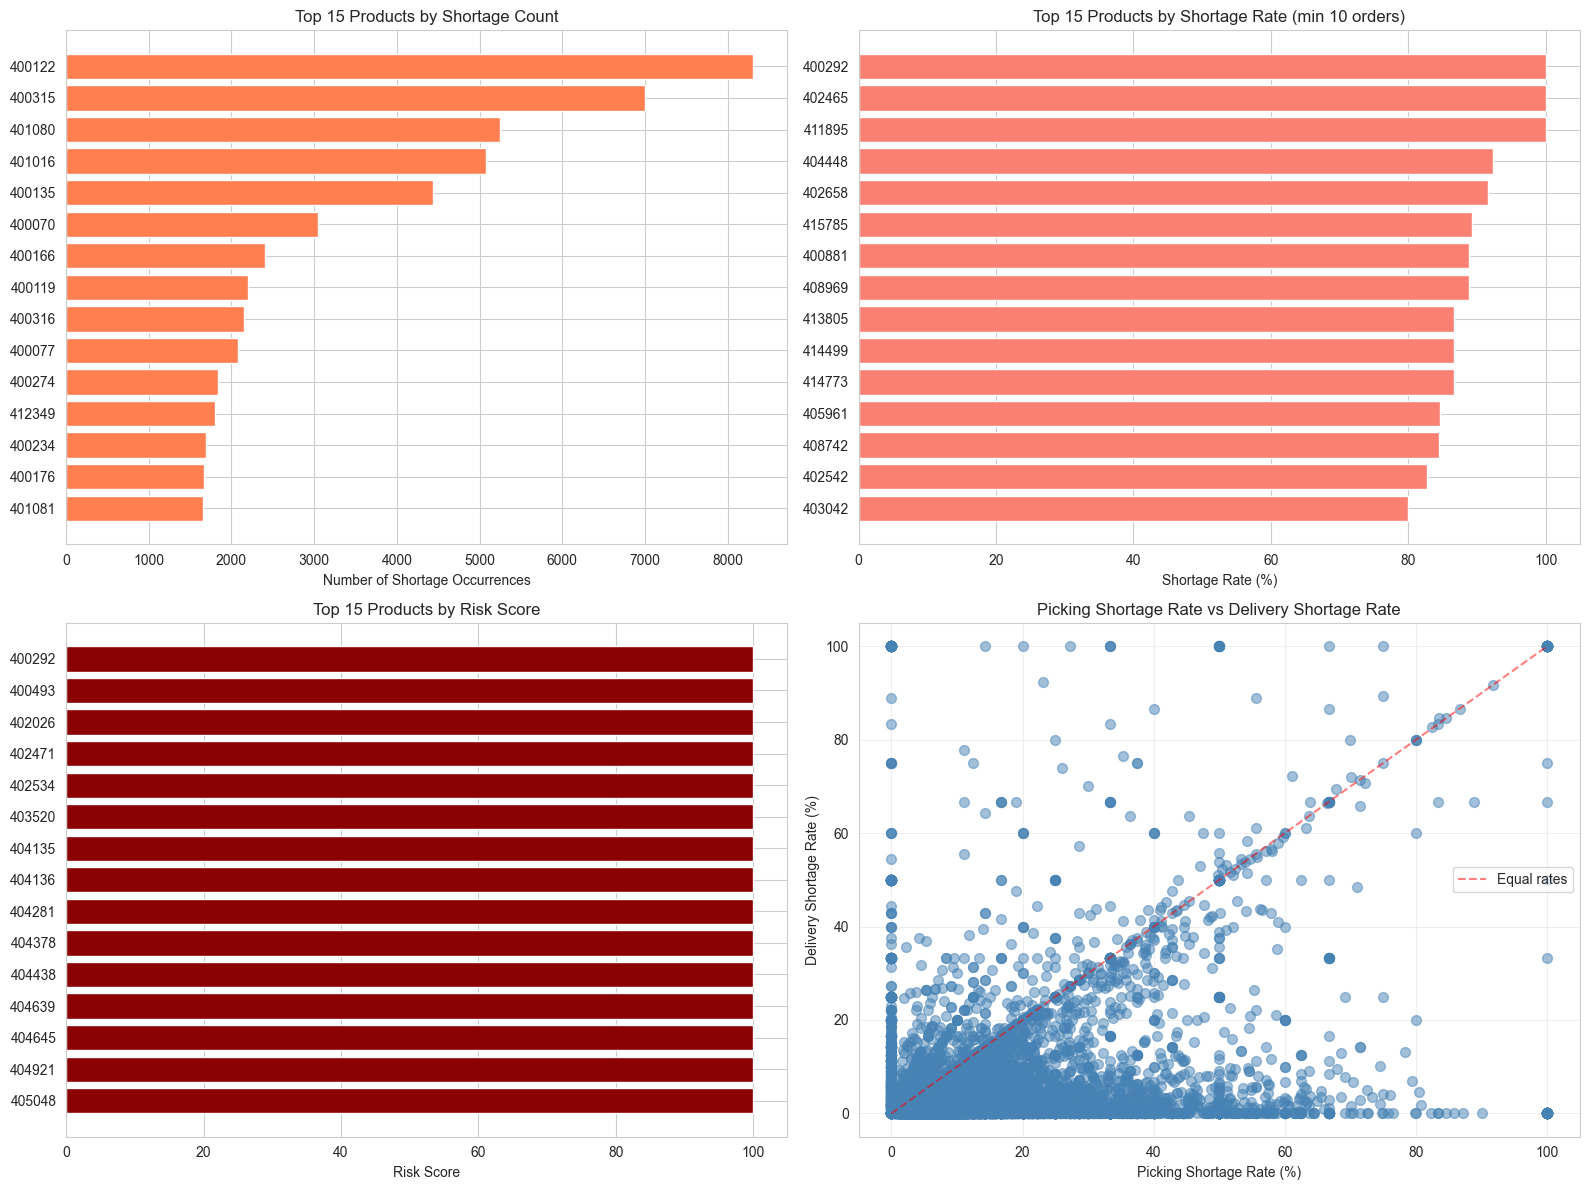


Products with shortages discovered at picking: 11234
Products with shortages discovered after picking: 1248


In [7]:
# Visualize top products with shortages
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top products by shortage count
top_shortage_products = product_stats.nlargest(15, 'shortage_count')
axes[0, 0].barh(range(len(top_shortage_products)), top_shortage_products['shortage_count'], 
                color='coral')
axes[0, 0].set_yticks(range(len(top_shortage_products)))
axes[0, 0].set_yticklabels(top_shortage_products['product_code'])
axes[0, 0].set_xlabel('Number of Shortage Occurrences')
axes[0, 0].set_title('Top 15 Products by Shortage Count')
axes[0, 0].invert_yaxis()

# 2. Top products by shortage rate
top_rate_products = product_stats[product_stats['total_orders'] >= 10].nlargest(15, 'shortage_rate')
axes[0, 1].barh(range(len(top_rate_products)), top_rate_products['shortage_rate'], 
                color='salmon')
axes[0, 1].set_yticks(range(len(top_rate_products)))
axes[0, 1].set_yticklabels(top_rate_products['product_code'])
axes[0, 1].set_xlabel('Shortage Rate (%)')
axes[0, 1].set_title('Top 15 Products by Shortage Rate (min 10 orders)')
axes[0, 1].invert_yaxis()

# 3. Top products by risk score
top_risk_products = product_stats.nlargest(15, 'risk_score')
axes[1, 0].barh(range(len(top_risk_products)), top_risk_products['risk_score'], 
                color='darkred')
axes[1, 0].set_yticks(range(len(top_risk_products)))
axes[1, 0].set_yticklabels(top_risk_products['product_code'])
axes[1, 0].set_xlabel('Risk Score')
axes[1, 0].set_title('Top 15 Products by Risk Score')
axes[1, 0].invert_yaxis()

# 4. Picking vs Delivery shortages
axes[1, 1].scatter(product_stats['picking_shortage_rate'], product_stats['shortage_rate'], 
                   alpha=0.5, color='steelblue', s=50)
axes[1, 1].set_xlabel('Picking Shortage Rate (%)')
axes[1, 1].set_ylabel('Delivery Shortage Rate (%)')
axes[1, 1].set_title('Picking Shortage Rate vs Delivery Shortage Rate')
axes[1, 1].plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Equal rates')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nProducts with shortages discovered at picking: {(product_stats['picking_shortage_rate'] > 0).sum()}")
print(f"Products with shortages discovered after picking: {(product_stats['shortage_rate'] > product_stats['picking_shortage_rate']).sum()}")


## 4. Customer Impact Analysis


In [8]:
# Customer-level shortage analysis
customer_stats = aggregated.groupby('customer_number').agg({
    'order_number': 'count',  # Total orders
    'has_shortage': 'sum',  # Count of shortages
    'shortage_qty': 'sum',  # Total shortage quantity
    'order_qty': 'sum',  # Total ordered
    'delivered_qty': 'sum',  # Total delivered
    'product_code': 'nunique',  # Unique products ordered
    'shortage_pct': 'mean',  # Average shortage percentage
    'shortage_discovered_at_picking': 'sum',  # Shortages caught early
    'shortage_discovered_after_picking': 'sum'  # Shortages caught late
}).reset_index()

customer_stats.columns = ['customer_number', 'total_orders', 'shortage_count', 'total_shortage_qty', 
                         'total_ordered_qty', 'total_delivered_qty', 'unique_products', 'avg_shortage_pct',
                         'shortages_at_picking', 'shortages_after_picking']

# Calculate metrics
customer_stats['shortage_rate'] = (customer_stats['shortage_count'] / customer_stats['total_orders'] * 100)
customer_stats['fulfillment_rate'] = (customer_stats['total_delivered_qty'] / customer_stats['total_ordered_qty'] * 100)
customer_stats['late_discovery_rate'] = (customer_stats['shortages_after_picking'] / customer_stats['shortage_count'] * 100).replace([np.inf, -np.inf], 0)

customer_stats['impact_score'] = (
    (customer_stats['shortage_rate'] / 100) * 0.5 +  # 50% weight on frequency
    (1 - customer_stats['fulfillment_rate'] / 100) * 0.3 +  # 30% weight on severity
    (customer_stats['total_orders'] / customer_stats['total_orders'].max()) * 0.2  # 20% weight on volume
) * 100

print("Top 20 Customers by Impact Score (Most Affected):")
print(customer_stats.nlargest(20, 'impact_score')[['customer_number', 'total_orders', 'shortage_count', 
                                                    'shortage_rate', 'late_discovery_rate', 
                                                    'fulfillment_rate', 'impact_score']])


Top 20 Customers by Impact Score (Most Affected):
      customer_number  total_orders  shortage_count  shortage_rate  \
1696            32282             1               1         100.00   
2304            32890             1               1         100.00   
2315            32901             1               1         100.00   
4558            35144             1               1         100.00   
2389            32975             1               1         100.00   
2379            32965             1               1         100.00   
2678            33264             1               1         100.00   
2124            32710             1               1         100.00   
2227            32813             1               1         100.00   
548             31134             1               1         100.00   
1218            31804             5               3          60.00   
1759            32345             5               3          60.00   
4833            35419             2     

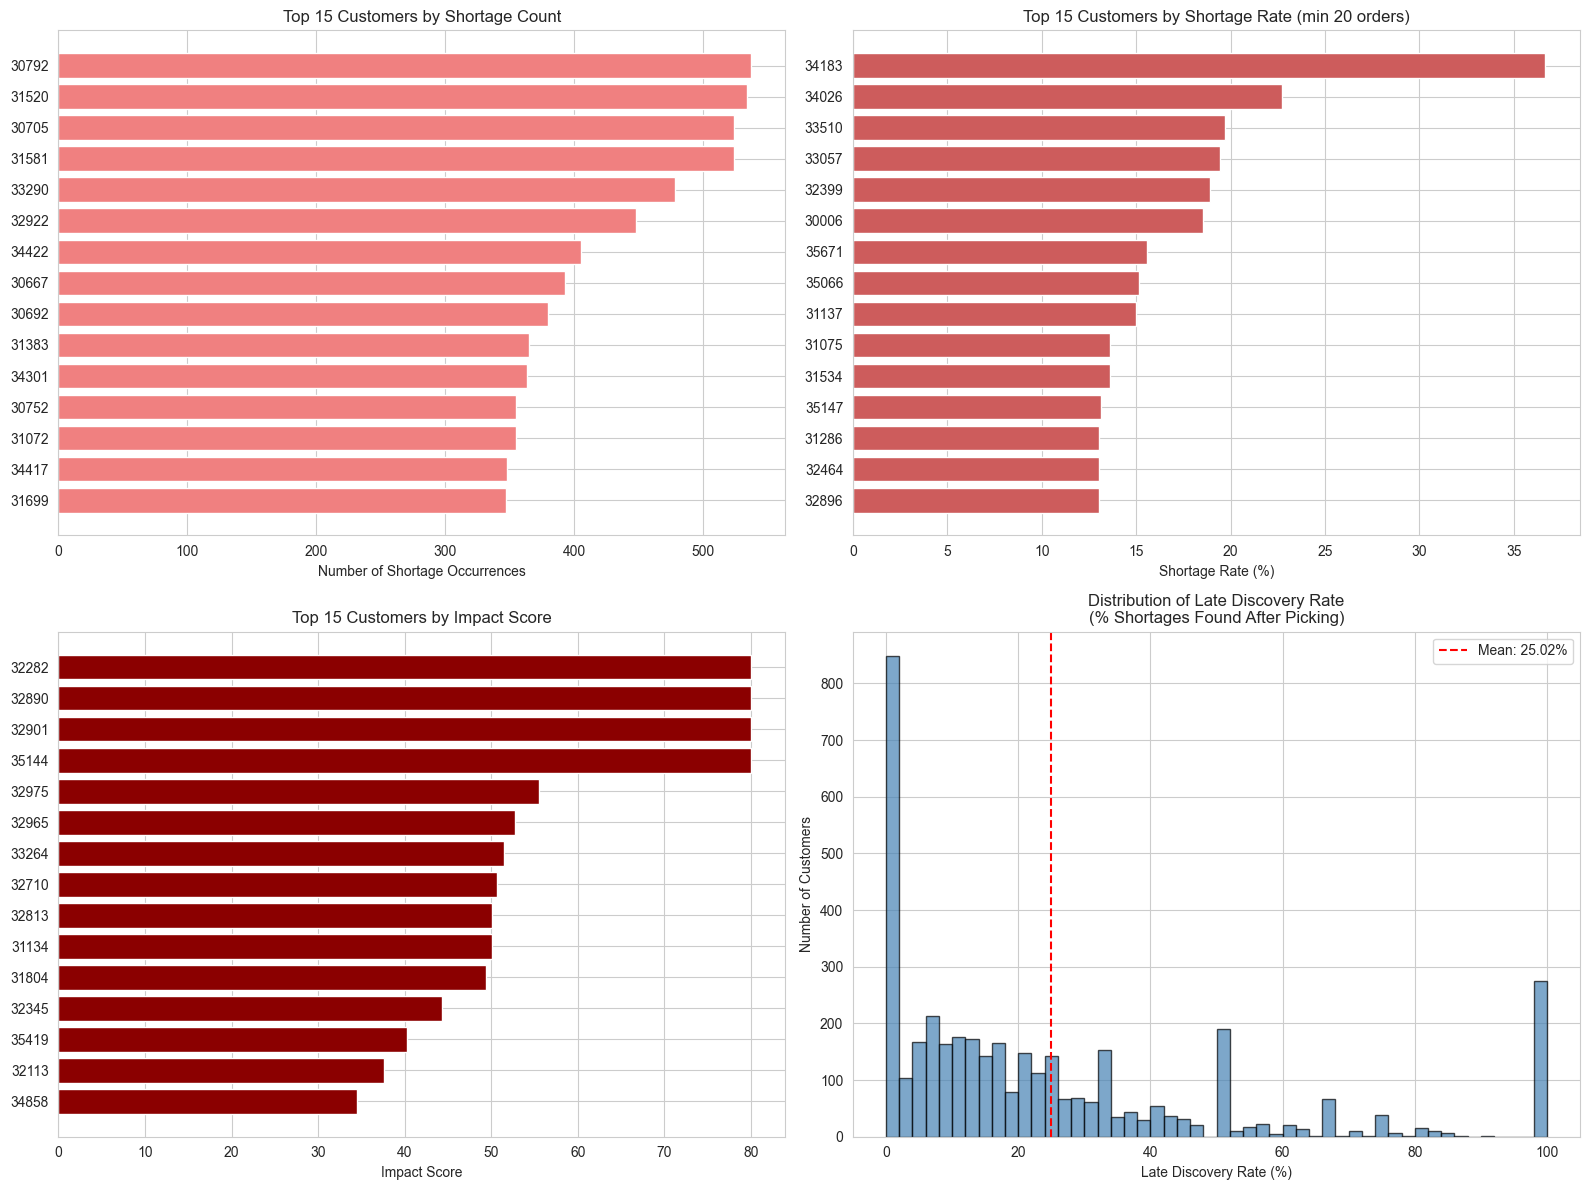

In [9]:
# Visualize customer impact
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top customers by shortage count
top_shortage_customers = customer_stats.nlargest(15, 'shortage_count')
axes[0, 0].barh(range(len(top_shortage_customers)), top_shortage_customers['shortage_count'], 
                color='lightcoral')
axes[0, 0].set_yticks(range(len(top_shortage_customers)))
axes[0, 0].set_yticklabels(top_shortage_customers['customer_number'])
axes[0, 0].set_xlabel('Number of Shortage Occurrences')
axes[0, 0].set_title('Top 15 Customers by Shortage Count')
axes[0, 0].invert_yaxis()

# 2. Top customers by shortage rate
top_rate_customers = customer_stats[customer_stats['total_orders'] >= 20].nlargest(15, 'shortage_rate')
if len(top_rate_customers) > 0:
    axes[0, 1].barh(range(len(top_rate_customers)), top_rate_customers['shortage_rate'], 
                    color='indianred')
    axes[0, 1].set_yticks(range(len(top_rate_customers)))
    axes[0, 1].set_yticklabels(top_rate_customers['customer_number'])
    axes[0, 1].set_xlabel('Shortage Rate (%)')
    axes[0, 1].set_title('Top 15 Customers by Shortage Rate (min 20 orders)')
    axes[0, 1].invert_yaxis()
else:
    axes[0, 1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Top Customers by Shortage Rate')

# 3. Top customers by impact score
top_impact_customers = customer_stats.nlargest(15, 'impact_score')
axes[1, 0].barh(range(len(top_impact_customers)), top_impact_customers['impact_score'], 
                color='darkred')
axes[1, 0].set_yticks(range(len(top_impact_customers)))
axes[1, 0].set_yticklabels(top_impact_customers['customer_number'])
axes[1, 0].set_xlabel('Impact Score')
axes[1, 0].set_title('Top 15 Customers by Impact Score')
axes[1, 0].invert_yaxis()

# 4. Late discovery rate distribution
axes[1, 1].hist(customer_stats[customer_stats['shortage_count'] > 0]['late_discovery_rate'], 
                bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Late Discovery Rate (%)')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].set_title('Distribution of Late Discovery Rate\n(% Shortages Found After Picking)')
if (customer_stats['shortage_count'] > 0).sum() > 0:
    mean_late = customer_stats[customer_stats['shortage_count'] > 0]['late_discovery_rate'].mean()
    axes[1, 1].axvline(mean_late, color='red', linestyle='--', 
                       label=f"Mean: {mean_late:.2f}%")
    axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 5. Temporal Pattern Analysis


In [10]:
# Monthly shortage patterns
monthly_stats = aggregated.groupby('order_created_month').agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum',
    'shortage_discovered_at_picking': 'sum',
    'shortage_discovered_after_picking': 'sum'
}).reset_index()

monthly_stats['shortage_rate'] = (monthly_stats['has_shortage'] / monthly_stats['order_number'] * 100)
monthly_stats['early_detection_rate'] = (monthly_stats['shortage_discovered_at_picking'] / 
                                         monthly_stats['has_shortage'] * 100).replace([np.inf, -np.inf], 0)

# Weekly patterns
weekly_stats = aggregated.groupby('order_created_week').agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum'
}).reset_index()

weekly_stats['shortage_rate'] = (weekly_stats['has_shortage'] / weekly_stats['order_number'] * 100)

# Day of week patterns
day_stats = aggregated.groupby(['order_created_dayofweek', 'order_created_dayname']).agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum'
}).reset_index()

day_stats['shortage_rate'] = (day_stats['has_shortage'] / day_stats['order_number'] * 100)
day_stats = day_stats.sort_values('order_created_dayofweek')

print("Monthly Shortage Patterns:")
print(monthly_stats[['order_created_month', 'order_number', 'has_shortage', 'shortage_rate', 'early_detection_rate']])
print("\nDay of Week Shortage Patterns:")
print(day_stats[['order_created_dayname', 'order_number', 'has_shortage', 'shortage_rate']])


Monthly Shortage Patterns:
    order_created_month  order_number  has_shortage  shortage_rate  \
0                     1        529217         11406           2.16   
1                     2        504993         10007           1.98   
2                     3        554439         10623           1.92   
3                     4        563697         11819           2.10   
4                     5        568710         11817           2.08   
5                     6        547736         10739           1.96   
6                     7        508324          8652           1.70   
7                     8        582618         11500           1.97   
8                     9       1204477         25359           2.11   
9                    10        566375         12800           2.26   
10                   11        537264         12464           2.32   
11                   12        467258         11303           2.42   

    early_detection_rate  
0                  87.64  
1       

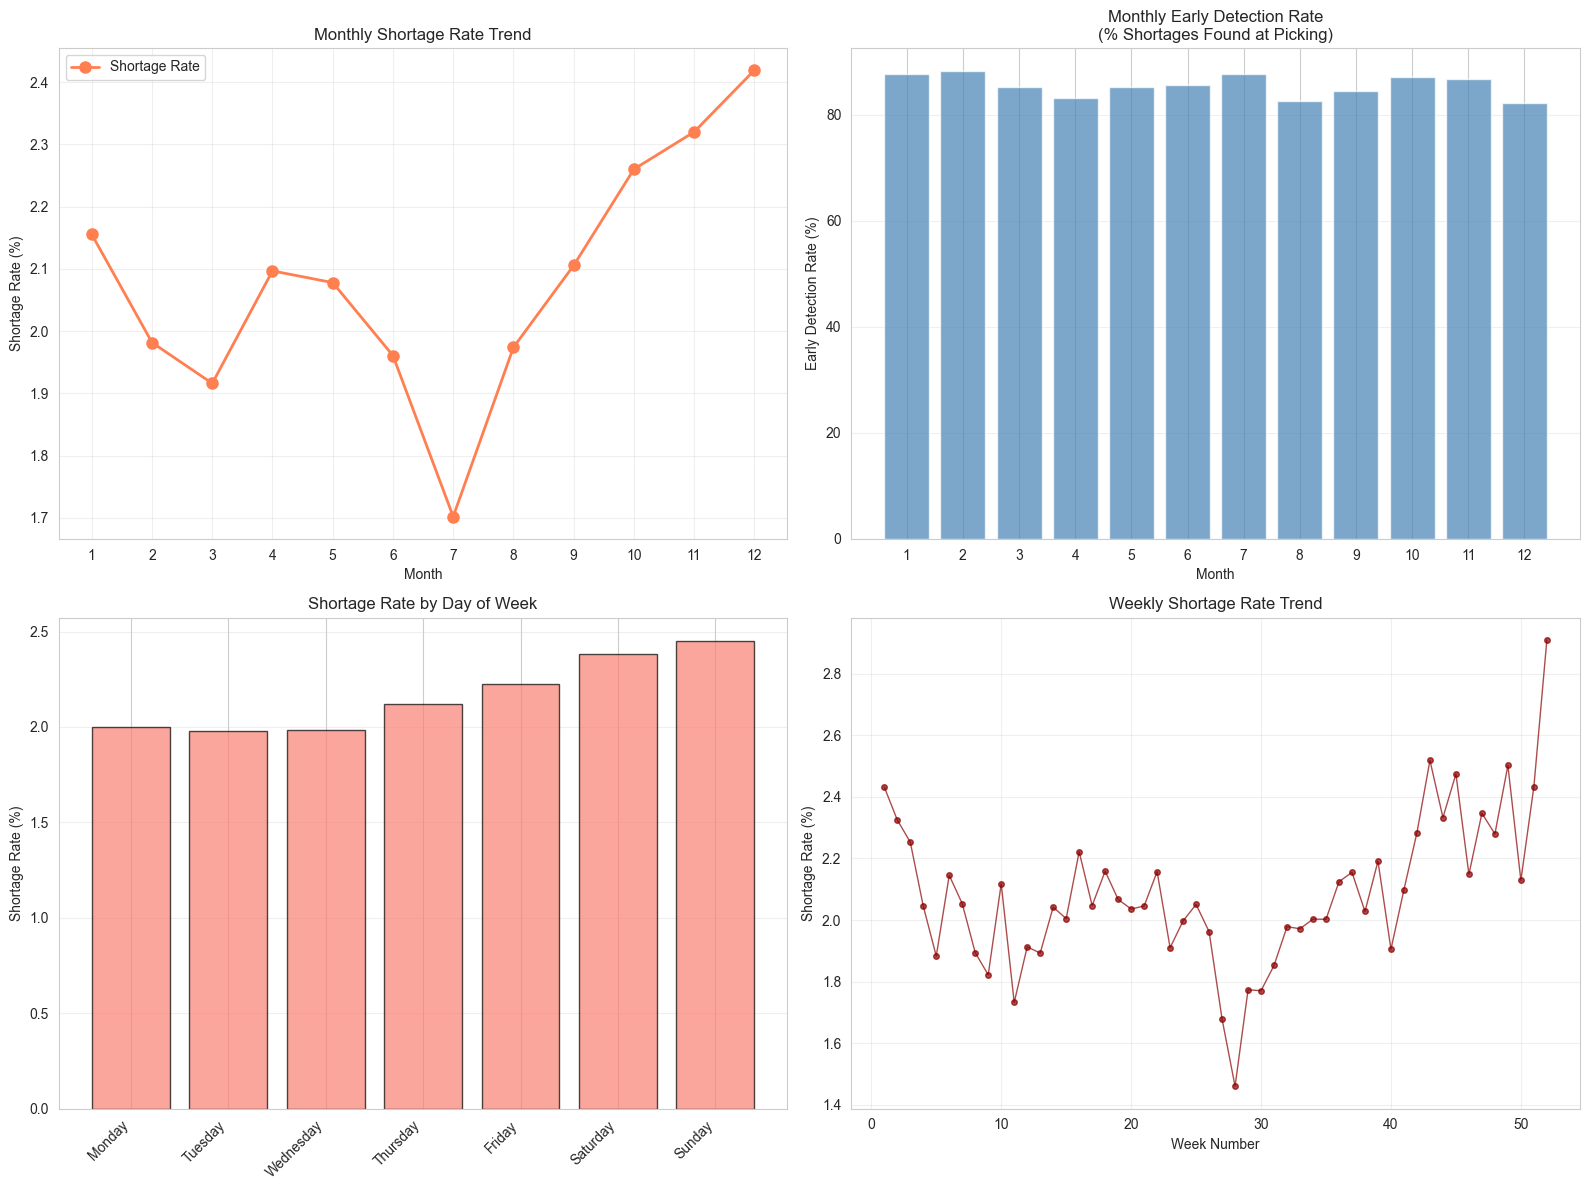

In [11]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Monthly shortage rate
axes[0, 0].plot(monthly_stats['order_created_month'], monthly_stats['shortage_rate'], 
                marker='o', linewidth=2, markersize=8, color='coral', label='Shortage Rate')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Shortage Rate (%)')
axes[0, 0].set_title('Monthly Shortage Rate Trend')
axes[0, 0].set_xticks(monthly_stats['order_created_month'])
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Monthly early detection rate
axes[0, 1].bar(monthly_stats['order_created_month'], monthly_stats['early_detection_rate'], 
               color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Early Detection Rate (%)')
axes[0, 1].set_title('Monthly Early Detection Rate\n(% Shortages Found at Picking)')
axes[0, 1].set_xticks(monthly_stats['order_created_month'])
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Day of week shortage rate
axes[1, 0].bar(range(len(day_stats)), day_stats['shortage_rate'], 
               color='salmon', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(day_stats)))
axes[1, 0].set_xticklabels(day_stats['order_created_dayname'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Shortage Rate (%)')
axes[1, 0].set_title('Shortage Rate by Day of Week')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Weekly shortage rate trend
axes[1, 1].plot(weekly_stats['order_created_week'], weekly_stats['shortage_rate'], 
                marker='o', linewidth=1, markersize=4, color='darkred', alpha=0.7)
axes[1, 1].set_xlabel('Week Number')
axes[1, 1].set_ylabel('Shortage Rate (%)')
axes[1, 1].set_title('Weekly Shortage Rate Trend')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Picking Pattern Analysis


In [12]:
# Analyze picking patterns and time windows
picking_stats = aggregated[aggregated['picking_hour'].notna()].copy()

# Picking time window analysis
time_window_stats = picking_stats.groupby('picking_time_window').agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'has_picking_shortage': 'sum',
    'shortage_qty': 'sum'
}).reset_index()

time_window_stats['shortage_rate'] = (time_window_stats['has_shortage'] / time_window_stats['order_number'] * 100)
time_window_stats['picking_shortage_rate'] = (time_window_stats['has_picking_shortage'] / time_window_stats['order_number'] * 100)

# Picking hour analysis
picking_hour_stats = picking_stats.groupby('picking_hour').agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'has_picking_shortage': 'sum'
}).reset_index()

picking_hour_stats['shortage_rate'] = (picking_hour_stats['has_shortage'] / picking_hour_stats['order_number'] * 100)
picking_hour_stats['picking_shortage_rate'] = (picking_hour_stats['has_picking_shortage'] / picking_hour_stats['order_number'] * 100)

print("Picking Time Window Analysis:")
print(time_window_stats)
print("\n\nPicking Hour Analysis (Top 10 hours by shortage rate):")
print(picking_hour_stats.nlargest(10, 'shortage_rate')[['picking_hour', 'order_number', 'has_shortage', 'shortage_rate', 'picking_shortage_rate']])


Picking Time Window Analysis:
  picking_time_window  order_number  has_shortage  has_picking_shortage  \
0        Early (0-6h)        903965         15231                 27236   
1     Morning (6-12h)       1849955         25052                 55043   
2  Afternoon (12-18h)       2383481         43945                 79671   
3    Evening (18-24h)       1480937         38907                 51718   

   shortage_qty  shortage_rate  picking_shortage_rate  
0     -19715.30           1.68                   3.01  
1     -19184.16           1.35                   2.98  
2     -49702.96           1.84                   3.34  
3     -41447.23           2.63                   3.49  


Picking Hour Analysis (Top 10 hours by shortage rate):
    picking_hour  order_number  has_shortage  shortage_rate  \
23         23.00        204322          6587           3.22   
21         21.00        230801          6393           2.77   
20         20.00        270542          7420           2.74   
19   

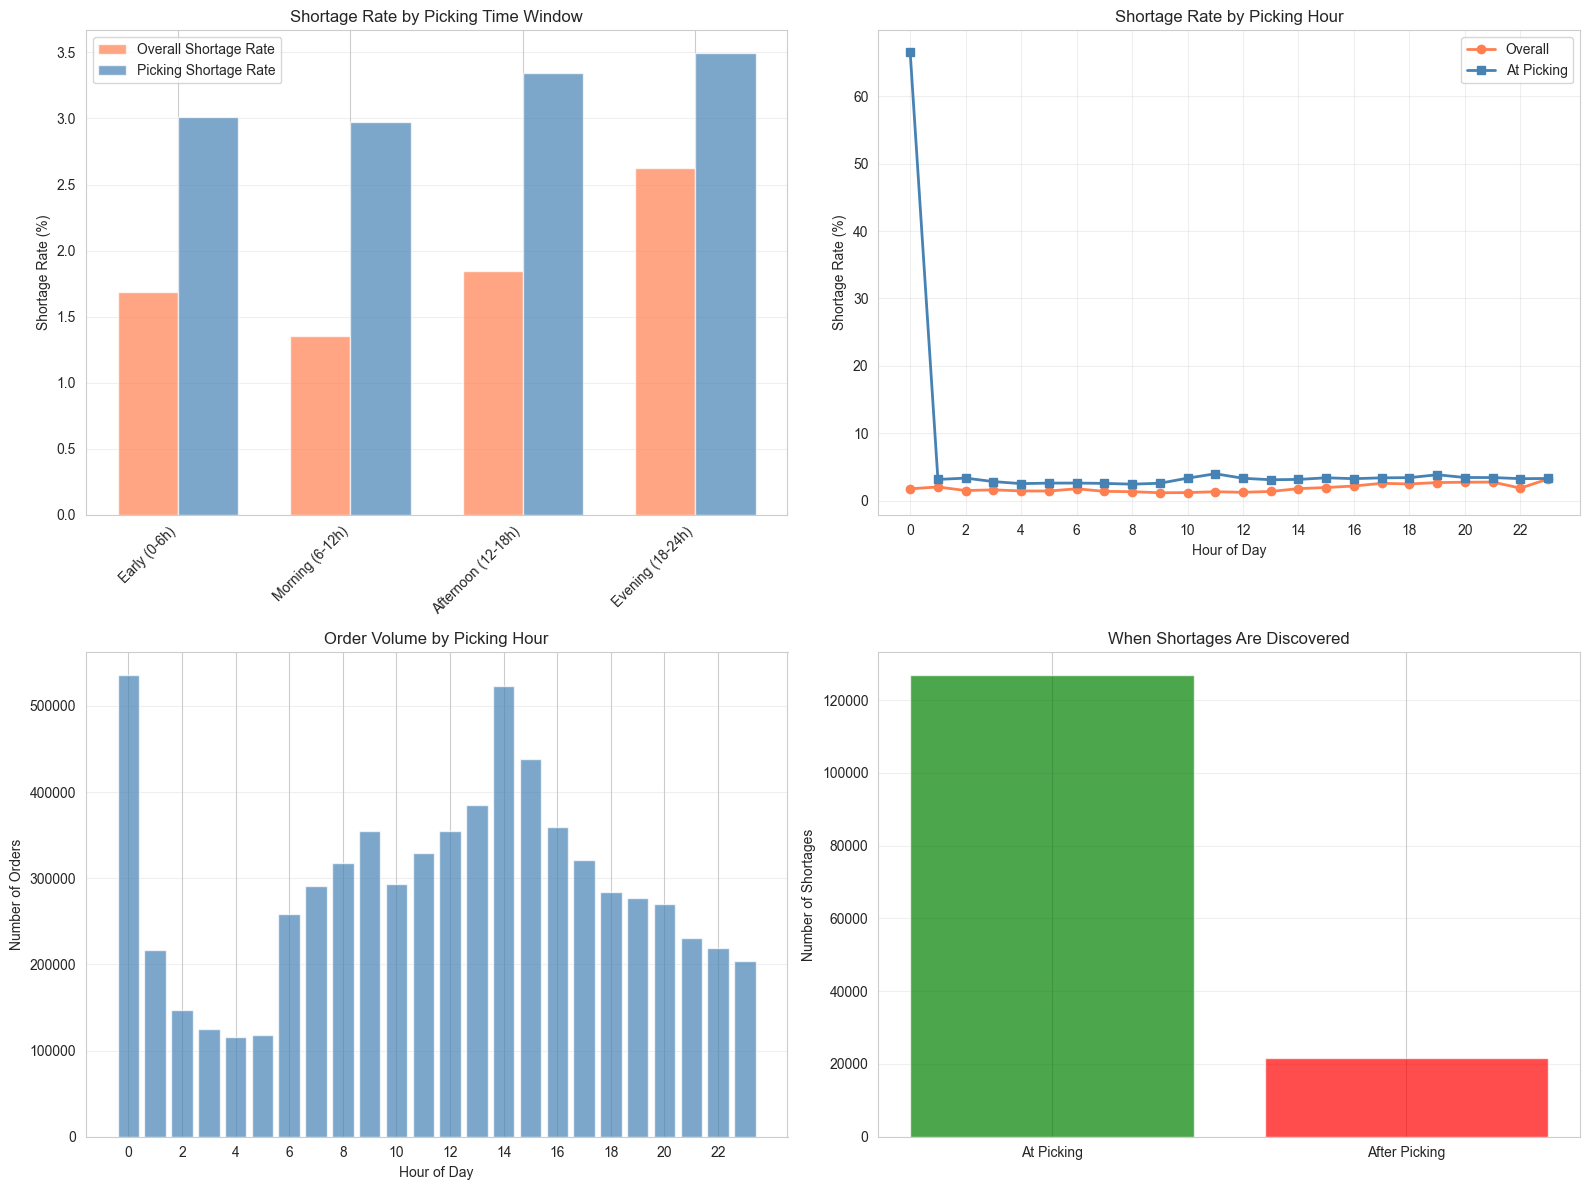


Shortage Discovery Timing:
Discovered at picking: 126762 (85.4%)
Discovered after picking: 21727 (14.6%)


In [13]:
# Visualize picking patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Picking time window shortage rates
if len(time_window_stats) > 0:
    x_pos = range(len(time_window_stats))
    width = 0.35
    axes[0, 0].bar([x - width/2 for x in x_pos], time_window_stats['shortage_rate'], 
                   width, label='Overall Shortage Rate', color='coral', alpha=0.7)
    axes[0, 0].bar([x + width/2 for x in x_pos], time_window_stats['picking_shortage_rate'], 
                   width, label='Picking Shortage Rate', color='steelblue', alpha=0.7)
    axes[0, 0].set_xticks(x_pos)
    axes[0, 0].set_xticklabels(time_window_stats['picking_time_window'], rotation=45, ha='right')
    axes[0, 0].set_ylabel('Shortage Rate (%)')
    axes[0, 0].set_title('Shortage Rate by Picking Time Window')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Picking hour shortage rate
axes[0, 1].plot(picking_hour_stats['picking_hour'], picking_hour_stats['shortage_rate'], 
                marker='o', linewidth=2, markersize=6, color='coral', label='Overall')
axes[0, 1].plot(picking_hour_stats['picking_hour'], picking_hour_stats['picking_shortage_rate'], 
                marker='s', linewidth=2, markersize=6, color='steelblue', label='At Picking')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Shortage Rate (%)')
axes[0, 1].set_title('Shortage Rate by Picking Hour')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(0, 24, 2))

# 3. Order volume by picking hour
axes[1, 0].bar(picking_hour_stats['picking_hour'], picking_hour_stats['order_number'], 
               color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Number of Orders')
axes[1, 0].set_title('Order Volume by Picking Hour')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_xticks(range(0, 24, 2))

# 4. Shortage discovery timing
discovery_timing = pd.DataFrame({
    'Discovery Point': ['At Picking', 'After Picking'],
    'Count': [
        aggregated['shortage_discovered_at_picking'].sum(),
        aggregated['shortage_discovered_after_picking'].sum()
    ]
})
axes[1, 1].bar(discovery_timing['Discovery Point'], discovery_timing['Count'], 
               color=['green', 'red'], alpha=0.7)
axes[1, 1].set_ylabel('Number of Shortages')
axes[1, 1].set_title('When Shortages Are Discovered')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

total_shortages = aggregated['has_shortage'].sum()
print(f"\nShortage Discovery Timing:")
print(f"Discovered at picking: {aggregated['shortage_discovered_at_picking'].sum()} ({aggregated['shortage_discovered_at_picking'].sum()/total_shortages*100:.1f}%)")
print(f"Discovered after picking: {aggregated['shortage_discovered_after_picking'].sum()} ({aggregated['shortage_discovered_after_picking'].sum()/total_shortages*100:.1f}%)")


## 7. Risk Scoring and Prioritization


In [14]:
# Create a comprehensive risk scoring system
# Combine product risk with customer impact

# Get high-risk products
high_risk_products = product_stats[product_stats['risk_score'] > 50].copy()
high_risk_products = high_risk_products.sort_values('risk_score', ascending=False)

# Get high-impact customers
high_impact_customers = customer_stats[customer_stats['impact_score'] > 30].copy()
high_impact_customers = high_impact_customers.sort_values('impact_score', ascending=False)

print("=== PRIORITY PRODUCTS FOR AI AGENT MONITORING ===")
print(f"Products with risk score > 50: {len(high_risk_products)}")
print("\nTop 30 High-Risk Products:")
print(high_risk_products[['product_code', 'total_orders', 'shortage_count', 
                          'shortage_rate', 'picking_shortage_rate', 
                          'fulfillment_rate', 'risk_score']].head(30))

print("\n\n=== PRIORITY CUSTOMERS FOR AI AGENT CONTACT ===")
print(f"Customers with impact score > 30: {len(high_impact_customers)}")
print("\nTop 30 High-Impact Customers:")
print(high_impact_customers[['customer_number', 'total_orders', 'shortage_count', 
                            'shortage_rate', 'late_discovery_rate', 
                            'fulfillment_rate', 'impact_score']].head(30))


=== PRIORITY PRODUCTS FOR AI AGENT MONITORING ===
Products with risk score > 50: 199

Top 30 High-Risk Products:
       product_code  total_orders  shortage_count  shortage_rate  \
271          400292            11              11         100.00   
8811         409940             1               1         100.00   
12012        413563             5               5         100.00   
11538        413026             2               2         100.00   
11289        412732             1               1         100.00   
11281        412724             1               1         100.00   
11109        412542             1               1         100.00   
9917         411177             5               5         100.00   
9575         410813             1               1         100.00   
9573         410809             3               3         100.00   
9314         410530             1               1         100.00   
9305         410521             2               2         100.00   
929

In [15]:
# Customer-Product combination analysis
customer_product_stats = aggregated.groupby(['customer_number', 'product_code']).agg({
    'order_number': 'count',
    'has_shortage': 'sum',
    'shortage_qty': 'sum',
    'shortage_pct': 'mean',
    'shortage_discovered_after_picking': 'sum'
}).reset_index()

customer_product_stats.columns = ['customer_number', 'product_code', 'order_count', 
                                  'shortage_count', 'total_shortage_qty', 'avg_shortage_pct',
                                  'late_discoveries']

customer_product_stats['shortage_rate'] = (customer_product_stats['shortage_count'] / 
                                           customer_product_stats['order_count'] * 100)

# Merge customer and product stats
customer_product_risk = customer_product_stats.merge(
    product_stats[['product_code', 'risk_score']], on='product_code', how='left'
).merge(
    customer_stats[['customer_number', 'impact_score']], on='customer_number', how='left'
)

# Calculate combined risk score (prioritize late discoveries)
customer_product_risk['combined_risk_score'] = (
    customer_product_risk['risk_score'].fillna(0) * 0.3 +  # Product risk (30%)
    customer_product_risk['impact_score'].fillna(0) * 0.3 +  # Customer impact (30%)
    (customer_product_risk['shortage_rate'] / 100) * 100 * 0.2 +  # Historical combo rate (20%)
    (customer_product_risk['late_discoveries'] / customer_product_risk['order_count'].max() * 100) * 0.2  # Late discovery (20%)
)

# Filter for actionable combinations (min 3 orders)
actionable_combinations = customer_product_risk[
    customer_product_risk['order_count'] >= 3
].sort_values('combined_risk_score', ascending=False)

print(f"=== AI AGENT ALERT TRIGGERS ===")
print(f"Customer-product combinations requiring immediate attention: {len(actionable_combinations[actionable_combinations['combined_risk_score'] > 40])}")
print("\nTop 30 High-Risk Customer-Product Combinations for AI Agent Alerts:")
print(actionable_combinations.head(30)[['customer_number', 'product_code', 'order_count', 
                                        'shortage_count', 'late_discoveries',
                                        'shortage_rate', 'combined_risk_score']])


=== AI AGENT ALERT TRIGGERS ===
Customer-product combinations requiring immediate attention: 40

Top 30 High-Risk Customer-Product Combinations for AI Agent Alerts:
        customer_number  product_code  order_count  shortage_count  \
333480            32118        413563            4               4   
633550            33613        410809            3               3   
909566            35240        400292            4               4   
751536            34310        409663            3               3   
932851            35329        407575            6               6   
910056            35241        400292            5               5   
113881            31197        408969            4               4   
238648            31717        410852            3               3   
419424            32644        400881            3               3   
546254            33282        408969           12              10   
569658            33350        414499            5               

## 8. Key Insights and Recommendations


In [16]:
print("="*80)
print("KEY INSIGHTS AND RECOMMENDATIONS FOR VALIO AIMO AI AGENT SYSTEM")
print("="*80)

print("\n1. PRODUCT RISK PRIORITIZATION:")
print(f"   - {len(high_risk_products)} products have high risk scores (>50)")
if len(high_risk_products) > 0:
    print(f"   - Top risk product: {int(high_risk_products.iloc[0]['product_code'])}")
    print(f"     (Risk Score: {high_risk_products.iloc[0]['risk_score']:.2f}, ")
    print(f"      Shortage Rate: {high_risk_products.iloc[0]['shortage_rate']:.2f}%)")
print("   - RECOMMENDATION: When these products are ordered, trigger immediate AI agent monitoring")

print("\n2. CUSTOMER IMPACT PRIORITIZATION:")
print(f"   - {len(high_impact_customers)} customers are highly impacted by shortages")
if len(high_impact_customers) > 0:
    print(f"   - Top impacted customer: {int(high_impact_customers.iloc[0]['customer_number'])}")
    print(f"     (Impact Score: {high_impact_customers.iloc[0]['impact_score']:.2f}, ")
    print(f"      Shortage Rate: {high_impact_customers.iloc[0]['shortage_rate']:.2f}%, ")
    print(f"      Late Discovery Rate: {high_impact_customers.iloc[0]['late_discovery_rate']:.2f}%)")
print("   - RECOMMENDATION: Proactively contact these customers for high-risk product orders")

print("\n3. SHORTAGE DISCOVERY TIMING:")
total_shortages = aggregated['has_shortage'].sum()
at_picking = aggregated['shortage_discovered_at_picking'].sum()
after_picking = aggregated['shortage_discovered_after_picking'].sum()
print(f"   - Shortages discovered at picking: {at_picking} ({at_picking/total_shortages*100:.1f}%)")
print(f"   - Shortages discovered after picking: {after_picking} ({after_picking/total_shortages*100:.1f}%)")
print("   - RECOMMENDATION: Focus AI agent on catching shortages during picking window")
print("     This enables proactive customer contact before delivery")

print("\n4. TEMPORAL PATTERNS:")
if len(monthly_stats) > 1:
    worst_month_idx = monthly_stats['shortage_rate'].idxmax()
    worst_month = monthly_stats.loc[worst_month_idx]
    print(f"   - Worst month: Month {int(worst_month['order_created_month'])}")
    print(f"     (Shortage Rate: {worst_month['shortage_rate']:.2f}%)")
if len(day_stats) > 0:
    worst_day_idx = day_stats['shortage_rate'].idxmax()
    worst_day = day_stats.loc[worst_day_idx]
    print(f"   - Worst day of week: {worst_day['order_created_dayname']}")
    print(f"     (Shortage Rate: {worst_day['shortage_rate']:.2f}%)")
if len(time_window_stats) > 0:
    worst_window_idx = time_window_stats['shortage_rate'].idxmax()
    worst_window = time_window_stats.loc[worst_window_idx]
    print(f"   - Worst picking time window: {worst_window['picking_time_window']}")
    print(f"     (Shortage Rate: {worst_window['shortage_rate']:.2f}%)")
print("   - RECOMMENDATION: Increase AI agent capacity during high-risk periods")

print("\n5. AI AGENT ALERT TRIGGERS:")
high_priority_combos = actionable_combinations[actionable_combinations['combined_risk_score'] > 40]
print(f"   - {len(high_priority_combos)} customer-product combinations require immediate alerts")
print("   - RECOMMENDATION: When these combinations occur, immediately trigger AI agent:")
print("     a. Pre-picking: Check stock availability")
print("     b. During picking: If shortage detected, contact customer proactively (VOICE FIRST)")
print("     c. Post-delivery: Follow up for any remaining issues")

print("\n6. MITIGATION SCALE RECOMMENDATION:")
print("   - Implement a 4-tier mitigation scale:")
print("     Tier 1 (Risk Score > 60): Immediate AI agent VOICE call + replacement proposal")
print("     Tier 2 (Risk Score 40-60): AI agent voice call during picking if shortage detected")
print("     Tier 3 (Risk Score 20-40): SMS/Text notification with replacement options")
print("     Tier 4 (Risk Score < 20): Standard process")
print("   - Priority: Focus on catching shortages DURING picking window for proactive contact")

print("\n7. PICKING WINDOW OPTIMIZATION:")
if len(time_window_stats) > 0:
    best_window = time_window_stats.loc[time_window_stats['early_detection_rate'].idxmax()]
    print(f"   - Best time window for early detection: {best_window['picking_time_window']}")
    print(f"     (Early Detection Rate: {best_window['early_detection_rate']:.2f}%)")
print("   - RECOMMENDATION: Optimize AI agent scheduling around high-risk picking windows")

print("\n" + "="*80)


KEY INSIGHTS AND RECOMMENDATIONS FOR VALIO AIMO AI AGENT SYSTEM

1. PRODUCT RISK PRIORITIZATION:
   - 199 products have high risk scores (>50)
   - Top risk product: 400292
     (Risk Score: 100.00, 
      Shortage Rate: 100.00%)
   - RECOMMENDATION: When these products are ordered, trigger immediate AI agent monitoring

2. CUSTOMER IMPACT PRIORITIZATION:
   - 54 customers are highly impacted by shortages
   - Top impacted customer: 32282
     (Impact Score: 80.00, 
      Shortage Rate: 100.00%, 
      Late Discovery Rate: 100.00%)
   - RECOMMENDATION: Proactively contact these customers for high-risk product orders

3. SHORTAGE DISCOVERY TIMING:
   - Shortages discovered at picking: 126762 (85.4%)
   - Shortages discovered after picking: 21727 (14.6%)
   - RECOMMENDATION: Focus AI agent on catching shortages during picking window
     This enables proactive customer contact before delivery

4. TEMPORAL PATTERNS:
   - Worst month: Month 12
     (Shortage Rate: 2.42%)
   - Worst day of 

KeyError: 'early_detection_rate'

## 9. Export Risk Scores for Integration


In [ ]:
# Export key risk scores for integration with AI agent system

# Product risk scores
product_risk_export = product_stats[['product_code', 'total_orders', 'shortage_rate', 
                                     'picking_shortage_rate', 'fulfillment_rate', 'risk_score']].copy()
product_risk_export = product_risk_export.sort_values('risk_score', ascending=False)

# Customer impact scores
customer_impact_export = customer_stats[['customer_number', 'total_orders', 'shortage_rate', 
                                         'late_discovery_rate', 'fulfillment_rate', 'impact_score']].copy()
customer_impact_export = customer_impact_export.sort_values('impact_score', ascending=False)

# High-priority combinations
priority_combos_export = actionable_combinations[
    actionable_combinations['combined_risk_score'] > 40
][['customer_number', 'product_code', 'order_count', 'shortage_count', 'late_discoveries',
   'shortage_rate', 'combined_risk_score']].copy()

print("Exporting risk scores...")
product_risk_export.to_csv('sales_product_risk_scores.csv', index=False)
customer_impact_export.to_csv('sales_customer_impact_scores.csv', index=False)
priority_combos_export.to_csv('sales_ai_agent_priority_combinations.csv', index=False)

print(f"✓ Exported {len(product_risk_export)} product risk scores")
print(f"✓ Exported {len(customer_impact_export)} customer impact scores")
print(f"✓ Exported {len(priority_combos_export)} priority combinations for AI agent alerts")

print("\nThese CSV files can be integrated into the AI agent system for real-time risk assessment.")
print("Focus on catching shortages during the picking window for proactive customer contact.")
